<h1 style="text-align: center;"><b>EXPLORATORY DATA ANALYSIS (EDA)</b></h1>

<h4 style="text-align: center;"> Exploring the Texas Department of Family and Protective Services(DFPS) Child Protective Services(CPS) Removals by Region dataset from Fiscal Years (FY) 2016 to 2025.<h4>

<center><strong>created by Ashley Hendrix </strong></center>

Date create: 09/15/2026<br>
Last updated: 09/16/2026<br>
Status: COMPLETED

### **Libraries/Packages** used in this data analysis

- **Pandas** for data analysis,data manipuation and data cleaning
- **Numpy** for scientific computing, data science, and mathematical operations
- **MatplotLib** for creating data visulazations 
- **Plotly** for browser based data visualization tool for interactve visuals
- **Seaborn** for data viszualation to create statistcal graphics

In [1]:
# Libraries and Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns

plt.style.use("ggplot")

### **Dataset Information**

**CPS 2.1 Removals - by Region with Child Demographics FY2016-2025**
According to the [TX DFPS Data and Decision Support](https://data.texas.gov/dataset/CPS-2-1-Removals-by-Region-with-Child-Demographics/izsm-24wy/about_data).

#### This dataset shows the data for CPS removals "a removal occurs when CPS determines that a child cannot safely remain in their own home and that DFPS needs to seek legal custody to ensure child safety. Removals can occur in an investigation, family preservation, family substitute care or family reunification stage."

#### This dataset contains 7 columns and 27,438 rows of data. Each row represents the fiscal year of the removal, the region of residence, the DFPS program stage the report was in during the removal, the sex, the race/ethnicity, age and the N children removed.


In [2]:
# load dataset
df = pd.read_excel("CPS_2.1_Removals_by_Region_with_Child_Demographics_FY2016-2025.xlsx")

# preview the dataset
df.head()

,Fiscal Year,Region,Removal Stage,Sex,Race/Ethnicity,Age,Removals
0,2025,1-Lubbock,Family Preservation,Female,African American,0,1
1,2025,1-Lubbock,Family Preservation,Female,African American,1,2
2,2025,1-Lubbock,Family Preservation,Female,African American,2,1
3,2025,1-Lubbock,Family Preservation,Female,African American,3,0
4,2025,1-Lubbock,Family Preservation,Female,African American,4,0


### **Dataset Column Details**

- Fiscal Year : *Texas DFPS fiscal year begins September 1st of the previous year and ends August 31st of the current year.*
    - **FY2016** (Sept. 1, 2015 - Aug 31,2016)
    - **FY2017** (Sept. 1, 2016 - Aug 31,2017) 
    - **FY2018** (Sept. 1, 2017 - Aug 31,2018) 
    - **FY2019** (Sept. 1, 2018 - Aug 31,2019) 
    - **FY2020** (Sept. 1, 2019 - Aug 31,2020) 
    - **FY2021** (Sept. 1, 2020 - Aug 31,2021)  
    - **FY2022** (Sept. 1, 2021 - Aug 31,2022) 
    - **FY2023** (Sept. 1, 2022 - Aug 31,2023) 
    - **FY2024** (Sept. 1, 2023 - Aug 31,2024) 
    - **FY2025** (Sept. 1, 2024 - Aug 31,2025) <br>
    
- Region : *There are 11 DFPS regions, there were some removals conducted out of state, and some where the region of the child is unknow to the reporter.*
    - **1-Lubbock**
    - **2-Abilene**
    - **3-Arlington**     
    - **4-Tyler**   
    - **5-Beaumont**   
    - **6-Houston**  
    - **7-Austin**    
    - **8-San Antonio**
    - **9-Midland**
    - **10-El Paso**
    - **11-Edinburg** 
    - **Unknown**
    - **Out of State** <br>

- Removal Stage : *There are several stages in the CPS Program, the two that are represented in this dataset are as follows.* <br>
    - **Family Preservation** : Family Preservation Services (FPR) or Family Based Safety Services (FPR), FPR is under the umbrella of FPR. FPR are services provided to the child and the family by DFPS where the caregiver retains legal custody. According to [DFPS Data and Decision Support](https://data.texas.gov/dataset/CPS-1-3-FPR-Children-Entering-Family-Preservation/2hki-6gbm/about_data)<br>
    - **Investigation** : Investigation (INV) stage is the fact-finding phase where the state evalutes allegations of abuse, neglect or exploitation of a child under the age of 18 and not emancipated. This state comes after the intake has been assessed as meeting the guildlines of abuse, neglect or exploitation in the state of Texas, and is determined necessary by CPS staff in the region to which the report is assigned. <br>

- Sex : *"Sex means and individual's biological sex, either male or female. According to the [Texas Legislature House Bill No. 229.](https://capitol.texas.gov/tlodocs/89R/billtext/html/HB00229F.HTM)*
    - **Male** 
    - **Female** <br>



- Race/Ethnicity :
    - **African American**
    - **Anglo**
    - **Asian**
    - **Hispanic**
    - **Native American** 
    - **Other** <br>
    
- Age : *For the purpose of an investigation a child must be born alive and be under the age of 18 at the time of intake, however there are some rare special circumstances that may be present for Child Protective Services to interviene on an indivitals behalf outside of those parameter. However for this dataset children are between the ages of 0 meaning live birth and under the age of 18.* <br>

- Removals : *Represents the number of removals conducted for that specific fiscal year, region, removal stage, sex, race/ethnicity and age.*

In [3]:
# data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27438 entries, 0 to 27437
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Fiscal Year     27438 non-null  int64
 1   Region          27438 non-null  str  
 2   Removal Stage   27438 non-null  str  
 3   Sex             27438 non-null  str  
 4   Race/Ethnicity  27438 non-null  str  
 5   Age             27438 non-null  int64
 6   Removals        27438 non-null  int64
dtypes: int64(3), str(4)
memory usage: 2.5 MB


#### **Clean columns names**
***Standardizing column names for ease of use when calling and renameing***

In [4]:
# clean column names and format them
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

df.head()

,fiscal_year,region,removal_stage,sex,race/ethnicity,age,removals
0,2025,1-Lubbock,Family Preservation,Female,African American,0,1
1,2025,1-Lubbock,Family Preservation,Female,African American,1,2
2,2025,1-Lubbock,Family Preservation,Female,African American,2,1
3,2025,1-Lubbock,Family Preservation,Female,African American,3,0
4,2025,1-Lubbock,Family Preservation,Female,African American,4,0


In [ ]:
# view total value count for each removal stage
df.removal_stage.value_counts() # check if the sum of all removal stages equals the total removals



,fiscal_year,region,removal_stage,sex,race/ethnicity,age,removals
0,2025,1-Lubbock,Family Preservation,Female,African American,0,1
1,2025,1-Lubbock,Family Preservation,Female,African American,1,2
2,2025,1-Lubbock,Family Preservation,Female,African American,2,1
3,2025,1-Lubbock,Family Preservation,Female,African American,3,0
4,2025,1-Lubbock,Family Preservation,Female,African American,4,0
...,...,...,...,...,...,...,...
27433,2016,Unknown,Investigation,Male,African American,6,1
27434,2016,Unknown,Investigation,Male,Anglo,9,1
27435,2016,Unknown,Investigation,Male,Anglo,14,1
27436,2016,Out of State,Family Preservation,Female,African American,0,0


### **Summary Statistics**
***Using the pandas describe method to view statistical data for each colunm's values. Broken into Numerical data and Categorical data descriptors***

In [ ]:
# Data statistics for raw numerical data ( not weighted by the number of removals)
df[["fiscal_year", "age", "removals"]].describe(include="all").round(0)


,fiscal_year,age,removals
count,27438.0,27438.0,27438.0
mean,2020.0,8.0,5.0
std,3.0,5.0,10.0
min,2016.0,0.0,0.0
25%,2018.0,3.0,1.0
50%,2020.0,8.0,2.0
75%,2023.0,12.0,6.0
max,2025.0,17.0,192.0


In [27]:
# Data statistics for categorical data
df[["region", "race/ethnicity","sex", "removal_stage"]].describe()


,region,race/ethnicity,sex,removal_stage
count,27438,27438,27438,27438
unique,13,6,3,2
top,3-Arlington,Hispanic,Female,Family Preservation
freq,3212,7652,13776,13719


### **Missing values**

In [ ]:
# missing values in dataset
df.isnull().sum()

fiscal_year       0
region            0
removal_stage     0
sex               0
race/ethnicity    0
age               0
removals          0
dtype: int64

###  ***Univariate Analysis*** 
*A simple statistical data analysis that examines each variable (var) independently to understand its value distribution.*

#### **Numeric Variables**
**Fiscal Year**
The distribution of Fiscal Year shows how case counts vary across reporting years. This helps identify trends in removals over time, such as increases or decreases in workload or policy‑driven changes.

**Age**
The Age distribution highlights the age ranges most commonly represented in the dataset. This can reveal concentration around certain age groups, potential outliers, and demographic patterns relevant to DFPS casework.

**Removals**
The Removals variable shows how many removals occurred per record. Understanding this distribution helps identify whether removals are typically single‑event cases or whether multiple removals occur within the same reporting unit.

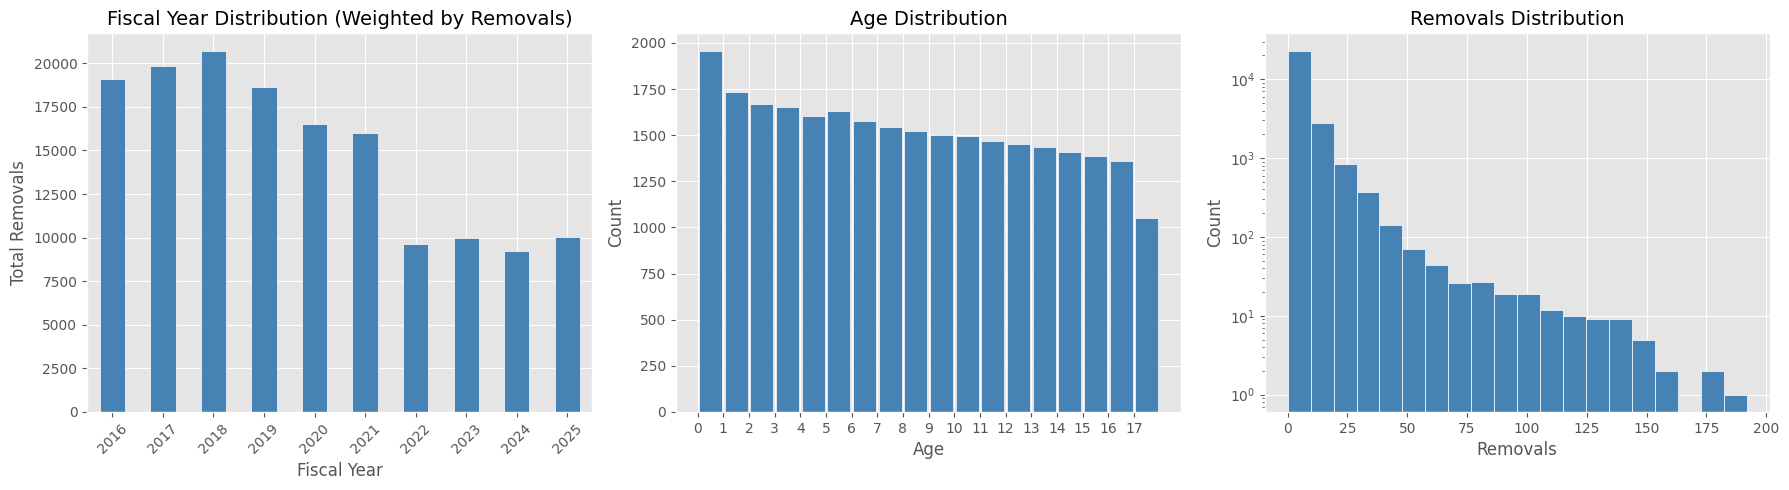

In [28]:
# Distribution of Fiscal Year, Age and Removals
plt.figure(figsize=(18, 5))

# Fiscal Year (weighted by the number of removals)
yr_custom_bins = np.arange(df['fiscal_year'].min(), df['fiscal_year'].max() + 2)  # +2 to include the last year in the bins
plt.subplot(1, 3, 1)
df.groupby('fiscal_year')['removals'].sum().plot(
    kind='bar',
    color='steelblue',
    edgecolor='white'
)
plt.title('Fiscal Year Distribution (Weighted by Removals)', fontsize=14)
plt.xlabel('Fiscal Year')
plt.ylabel('Total Removals')
plt.xticks(rotation=45)

# Age
custom_bins = np.arange(0, 19) 
plt.subplot(1, 3, 2)
plt.hist(df['age'].dropna(), bins=custom_bins, color='steelblue', edgecolor='white', rwidth=0.9)
plt.xticks(np.arange(0, 18))
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')

# Removals
plt.subplot(1, 3, 3)
plt.hist(df['removals'], bins=20, color='steelblue', edgecolor='white', log=True) # provide a log scale for better visualization of the distribution
plt.title('Removals Distribution', fontsize=14)
plt.xlabel('Removals')
plt.ylabel('Count')

plt.tight_layout()
plt.show()



#### **Categorical Variables**
**Region**
The Region variable shows how cases are distributed geographically across DFPS service regions. This helps identify regional workload differences and potential hotspots.

**Removal Stage**
The Removal Stage distribution highlights the point in the process where removals occur. This can reveal whether most removals happen early, during investigation, or later in the case lifecycle.

**Sex**
The Sex distribution provides insight into gender representation within the dataset. This helps identify demographic patterns and potential disparities.

**Race/Ethnicity**
The Race/Ethnicity variable shows the demographic composition of individuals represented in the dataset. This is essential for understanding population characteristics and identifying any disproportionality.


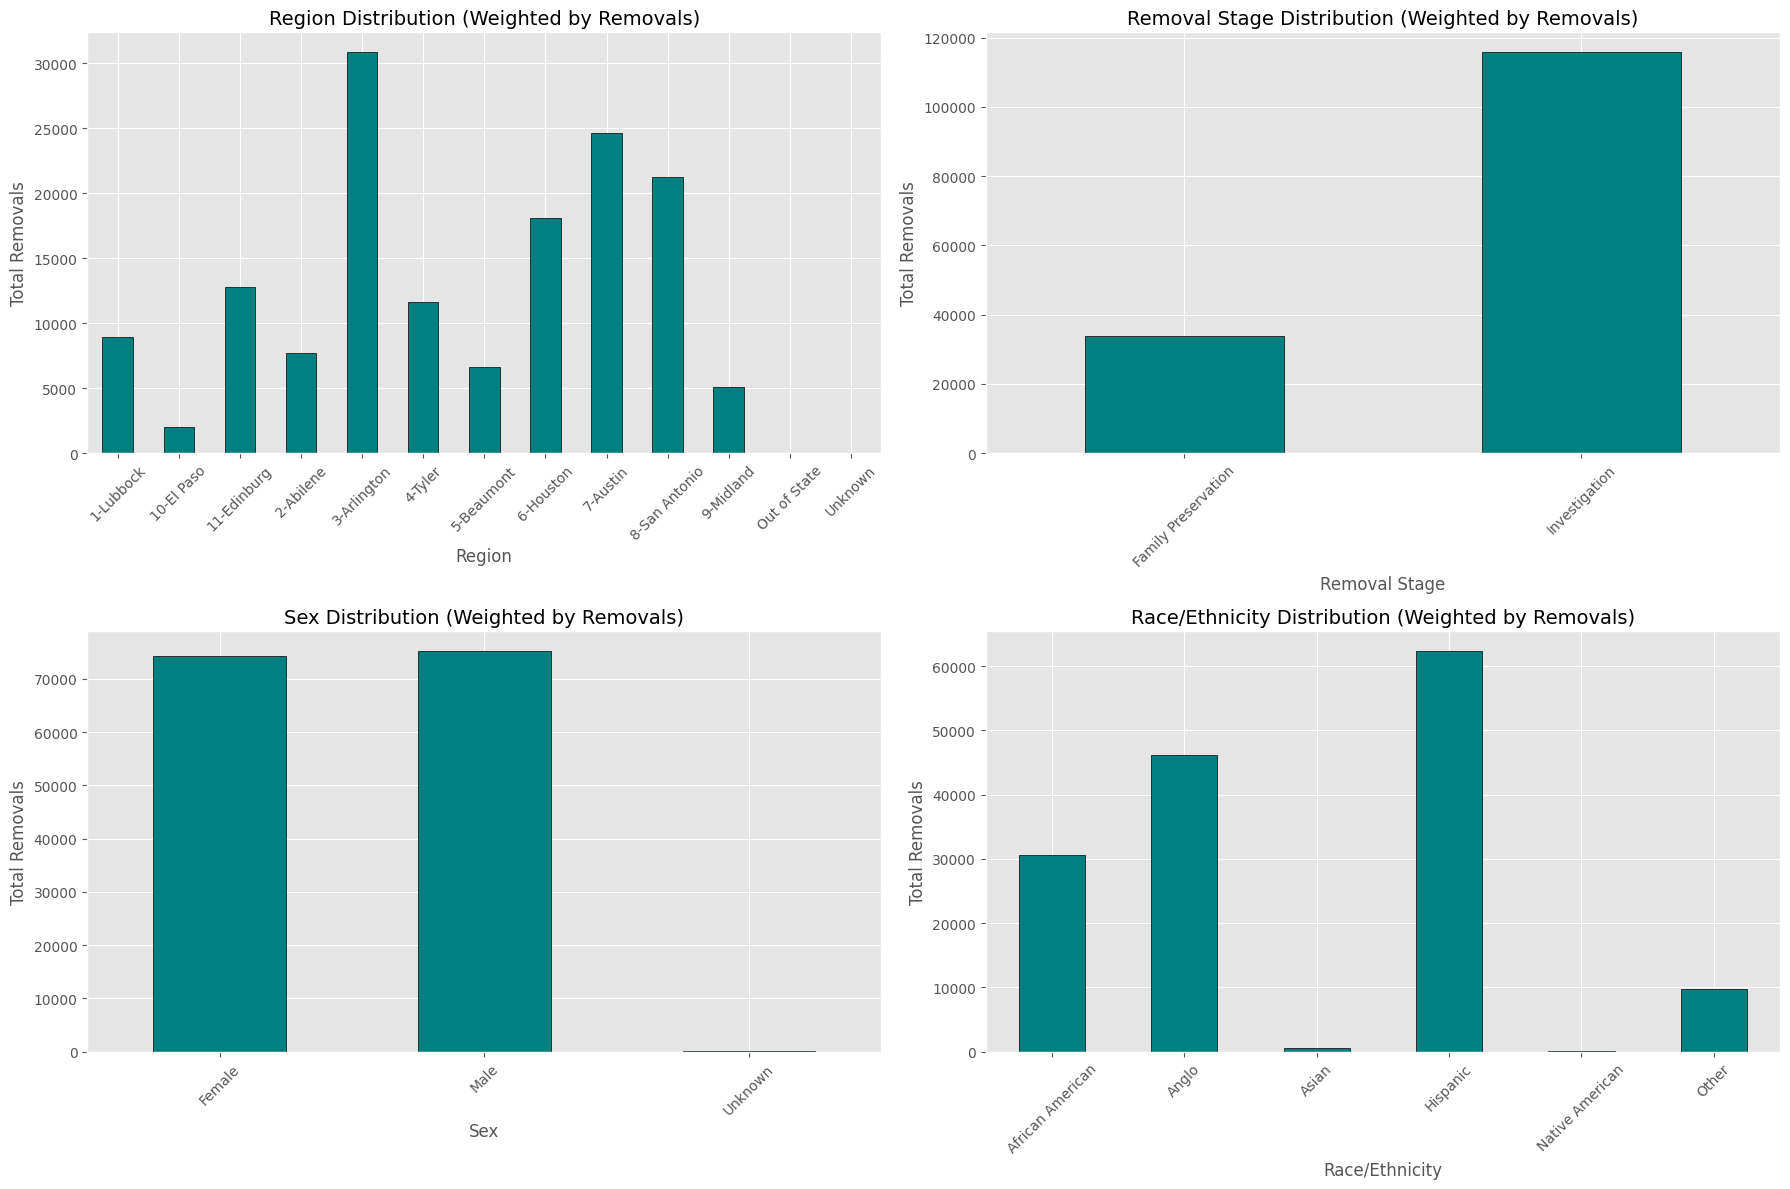

In [26]:
# Distribution of Region, Removal Stage, Sex, and Race/Ethnicity
# weighted by the number of removals to provide a more accurate representation of the data
categorical_cols = ['region', 'removal_stage', 'sex', 'race/ethnicity']

plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    df.groupby(col)['removals'].sum().plot(kind='bar', color='teal', edgecolor='black')
    plt.title(f'{col.replace("_", " ").title()} Distribution (Weighted by Removals)', fontsize=14)
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Total Removals')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Texas top 3 Regions

The counties in the top 3 DPFS regions with the highest removals also have some of Texas highest populations in the state of Texas. San Antonio in Bexar county is ranked second, Dallas in Dallas county is ranked third, Fort Worth in Tarrant county is ranked forth and Austin, in Travis county is ranked fifth.

- **Region 3 Arlington**
    - Major Counties/Cities: Tarrant/Arlington, Fort Worth, Dallas/Dallas, Collin/Plano
- **Region 7 Austin**
    - Major Counties/Cities: Travis/Austin, Williamson/Round Rock, Hays/Kyle
- **Region 8 San Antonio**
    -Major Counties/Cities: Bexar/San Antonio, Victoria/Victoria, Guadalupe/ Seguin



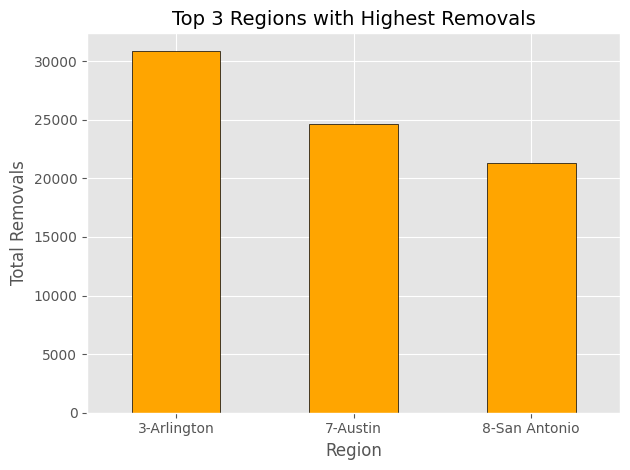

In [40]:
# Top three regions with the highest number of removals
top_regions = df.groupby('region')['removals'].sum().nlargest(3)

top_regions.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 3 Regions with Highest Removals', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Removals')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Top 5 Ages of children removed in Family Preservation (FPR) and Investigations (INV) Stages

Family Preservation (FPR)/Family-Based Safety Services(FBSS) and Investigations are two critical stages in child welfare. The at the INV stage Child Protective Investigations (CPI) can refer the family to FPR. 

Both the INV and FPR stages show similar trends with the majorty of children removed in each stage are the most vulderable in aged children ranging from live birth to 6years old.

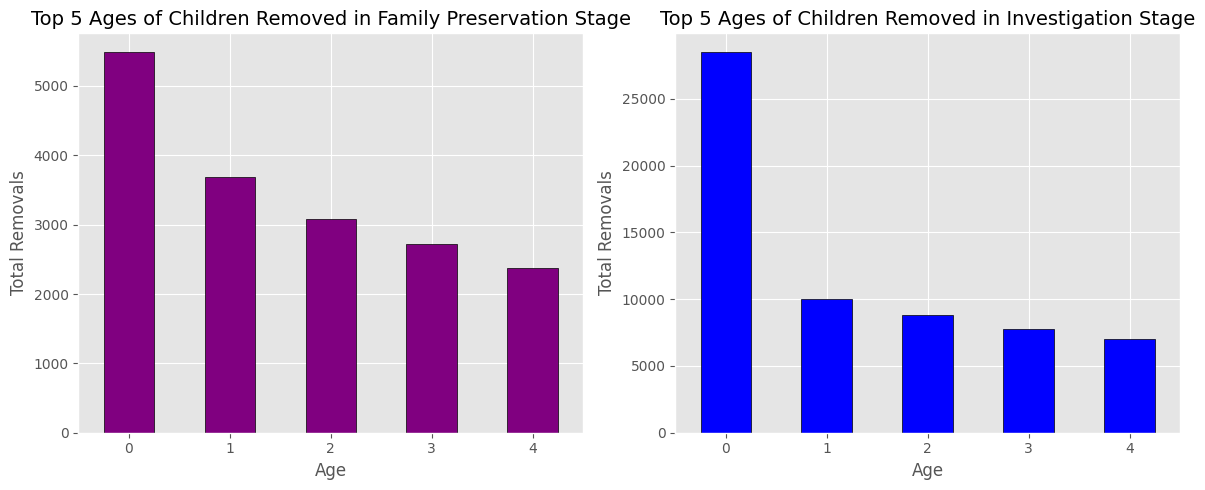

In [ ]:
# Top 5 age of chidren removed in FPR stange and top 5 ages of children removed in the Investigation stage by case.

top_5_age_FPR = (
    df[df['removal_stage'] == 'Family Preservation']
    .groupby('age')['removals']
    .sum()
    .nlargest(5)
)

top_5_age_investigation = (
    df[df['removal_stage'] == 'Investigation']
    .groupby('age')['removals']
    .sum()
    .nlargest(5)
)

#plot and subplots for the top 5 ages of children removed in FPR and Investigation stages
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
top_5_age_FPR.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Top 5 Ages of Children Removed in Family Preservation Stage', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Total Removals')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
top_5_age_investigation.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Top 5 Ages of Children Removed in Investigation Stage', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Total Removals')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Plotly interactive example
* This plotly interactive graph will be rendered static for the purpose of displaying it's contents on GitHub.

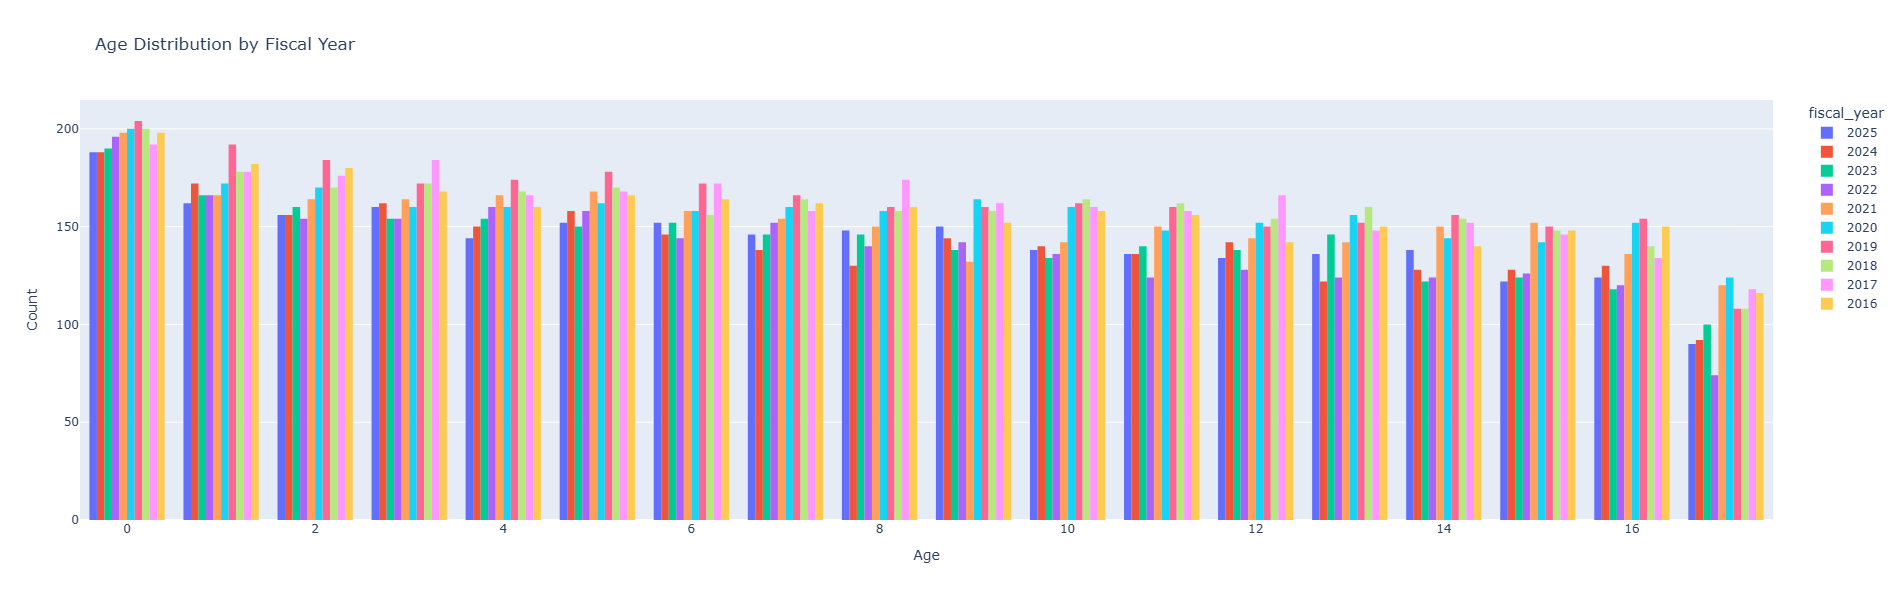

In [10]:
# Set the default renderer to PNG or SVG so it displays on GitHub

pio.renderers.default = "png" 

fig = px.histogram(df, x="age", color="fiscal_year", barmode="group", title="Age Distribution by Fiscal Year")  
fig.update_layout(xaxis_title="Age", 
                  yaxis_title="Count",
                  width=1900,
                  height=600,)
fig.show()

### Groupby Summaries for Numeric Variables 

- Age changes over time: total removals, average age of a child removed and the median age of the child during the fiscal year
- Race/Ethnicity changes over time: crosstab of race/ethnicity and removals during each fiscal year
- Removal stage over time:  percentage of removals that were conducted in the FPR and INV stages during the fiscal year
- Removals over time:  average count, median, and total count for removals over time



In [11]:
# how age has changed over time
summary_age_df = df.groupby('fiscal_year').agg(
    total_removals=('removals', 'sum'),
    average_age=('age', 'mean'),
    median_age=('age', 'median')
)

summary_age_df['avg_age'] = summary_age_df['average_age'].round(1)

summary_age_df[['total_removals', 'avg_age', 'median_age']]

,total_removals,avg_age,median_age
fiscal_year,,,
2016,19079,8.0,8.0
2017,19864,8.0,8.0
2018,20685,8.0,8.0
2019,18615,7.9,8.0
2020,16522,8.1,8.0
2021,16028,8.0,8.0
2022,9623,7.7,7.0
2023,9965,7.9,8.0
2024,9220,7.8,8.0


In [12]:
# how has race/ethnicity changed over time
# Flatten the categories into columns, summing up total removals
race_over_time = pd.crosstab(
    index=df['fiscal_year'], 
    columns=df['race/ethnicity'], 
    values=df['removals'], 
    aggfunc='sum'
).fillna(0)

race_over_time


race/ethnicity,African American,Anglo,Asian,Hispanic,Native American,Other
fiscal_year,,,,,,
2016,3735,6242,68,7809,21,1204
2017,3702,6434,68,8349,5,1306
2018,4421,6445,67,8402,12,1338
2019,3691,5902,84,7689,22,1227
2020,3292,5188,58,6977,19,988
2021,2991,5057,62,6891,5,1022
2022,2048,2959,49,3906,12,649
2023,2159,2968,43,4077,17,701
2024,2117,2441,57,4000,3,602


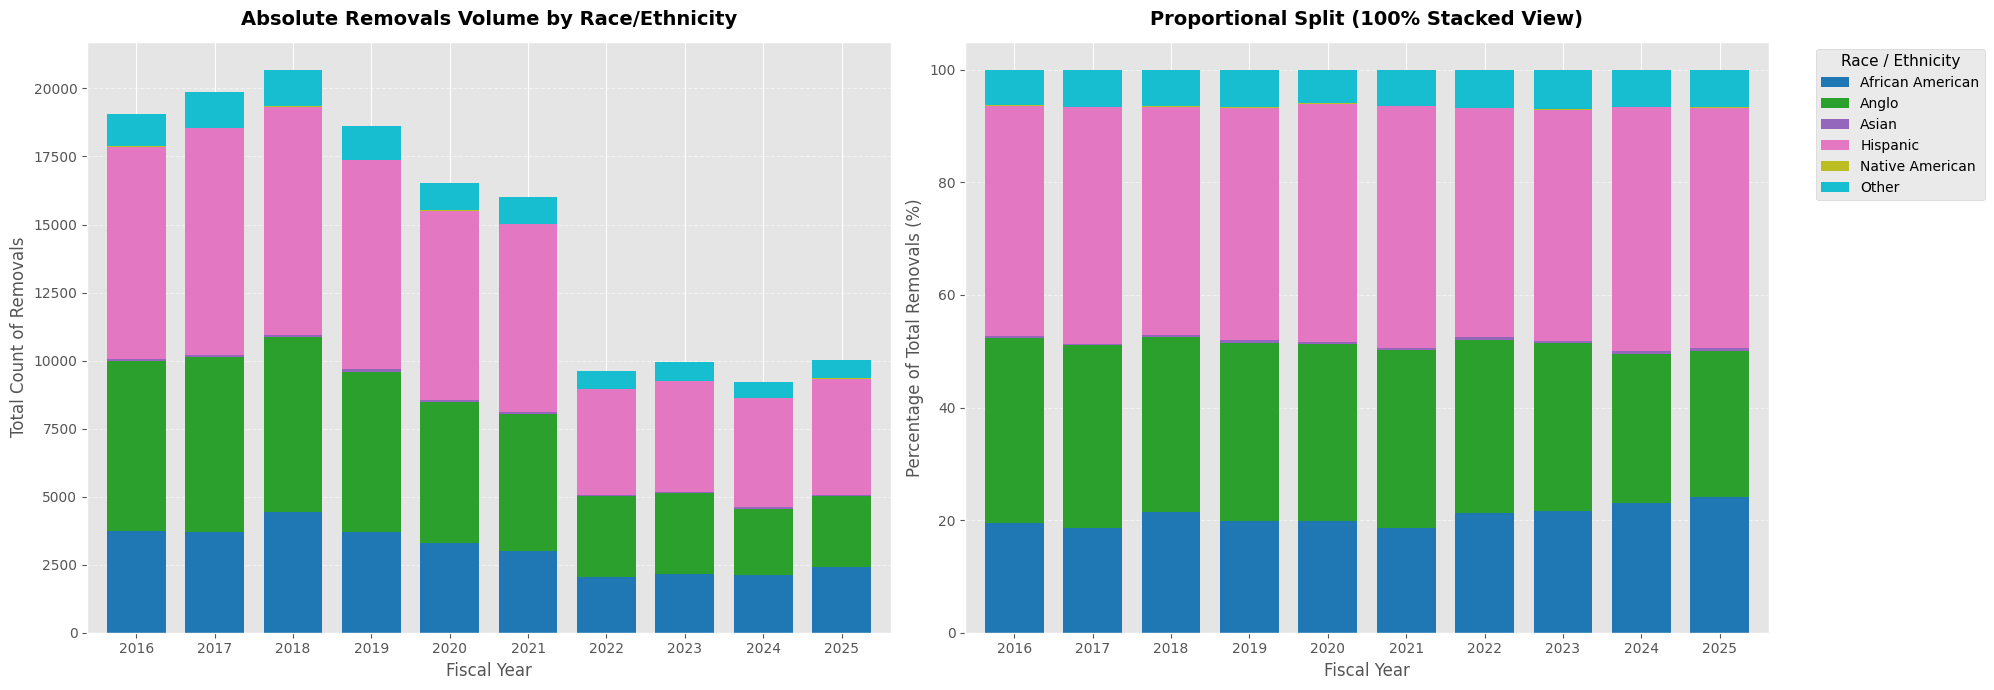

In [13]:
# GENERATE BOTH CROSSTAB MATRICES
# Absolute Count Matrix
race_absolute = pd.crosstab(
    index=df['fiscal_year'], 
    columns=df['race/ethnicity'], 
    values=df['removals'], 
    aggfunc='sum'
).fillna(0)

# Percentage Matrix (Normalized row-by-row)
race_percentage = pd.crosstab(
    index=df['fiscal_year'], 
    columns=df['race/ethnicity'], 
    values=df['removals'], 
    aggfunc='sum',
    normalize='index'
).fillna(0) * 100

# CREATE THE SIDE-BY-SIDE 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharex=False)
color_theme = 'tab10'  # Use a consistent palette so colors mean the same thing on both sides


# LEFT CHART: ABSOLUTE VOLUME (Stacked Bar)
race_absolute.plot(kind='bar', stacked=True, ax=ax1, colormap=color_theme, width=0.75, edgecolor='none')
ax1.set_title('Absolute Removals Volume by Race/Ethnicity', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Fiscal Year', fontsize=12)
ax1.set_ylabel('Total Count of Removals', fontsize=12)
ax1.set_xticklabels(race_absolute.index, rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.get_legend().remove()  # Hide this legend to prevent visual clutter


# RIGHT CHART: RELATIVE PERCENTAGE (100% Stacked Bar)
race_percentage.plot(kind='bar', stacked=True, ax=ax2, colormap=color_theme, width=0.75, edgecolor='none')
ax2.set_title('Proportional Split (100% Stacked View)', fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Fiscal Year', fontsize=12)
ax2.set_ylabel('Percentage of Total Removals (%)', fontsize=12)
ax2.set_xticklabels(race_percentage.index, rotation=0)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Move the single master legend completely outside the plots to the right side
ax2.legend(title='Race / Ethnicity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=11)

# Clean up structural layout padding and display
plt.tight_layout()
plt.show()


In [ ]:
# how removal stage has changed over time in percentage terms
removal_stage_over_time = pd.crosstab(
    index=df['fiscal_year'], 
    columns=df['removal_stage'], 
    values=df['removals'], 
    aggfunc='sum'
).fillna(0)

removal_stage_pct = removal_stage_over_time.div(removal_stage_over_time.sum(axis=1), axis=0).multiply(100).round(1)

removal_stage_pct




removal_stage,Family Preservation,Investigation
fiscal_year,,
2016,24.7,75.3
2017,25.6,74.4
2018,21.6,78.4
2019,21.6,78.4
2020,21.3,78.7
2021,19.4,80.6
2022,14.1,85.9
2023,21.8,78.2
2024,26.3,73.7


In [ ]:
# the average age of children in each removal stage over time
avg_age_stage_year = (
    df.groupby(['fiscal_year', 'removal_stage'])['age']
      .mean()
      .unstack()
      .round(2)
)

avg_age_stage_year


removal_stage,Family Preservation,Investigation
fiscal_year,,
2016,7.99,7.99
2017,8.00,8.00
2018,8.02,8.02
2019,7.94,7.94
2020,8.10,8.10
2021,8.03,8.03
2022,7.68,7.68
2023,7.85,7.85
2024,7.84,7.84


In [ ]:
# All removals by Fiscal Year
summary_df = df.groupby('fiscal_year')['removals'].agg(['mean', 'median', 'sum'])

# Flatten the multi-level headers (e.g., ('age', 'mean') becomes 'age_mean')
summary_df.columns = ['removals_mean', 'removals_median', 'removals_sum']

# drop unnecessary columns for a cleaner view
summary_df.style.format({
    'removals_mean': '{:.2f}',
    'removals_median': '{:.0f}',
    'removals_sum': '{:,.0f}'
})

,removals_mean,removals_median,removals_sum
fiscal_year,,,
2016,6.69,3,"19,079"
2017,6.82,3,"19,864"
2018,7.17,3,"20,685"
2019,6.30,2,"18,615"
2020,5.81,2,"16,522"
2021,5.82,2,"16,028"
2022,3.82,1,"9,623"
2023,3.87,2,"9,965"
2024,3.60,2,"9,220"


<center><h2><strong> Insight Summary of findings during the EDA process: Fiscal Years 2016 to 2025 </center>

The exploratory data analyiss of the DFPS dataset revealse several meaningful patterns across demographics, removal activity, and fiscal year trends. These insights help to clarify how cases evolve over time and highlight areas where deeper analysis or data cleaning may be beneficial.


## DATA SPECIFIC INSIGHTS

### **FISCAL YEAR DISTRIBUTION** 
#### **Key Finding: Pandemic-Era Shifts in Case Volume and Removals**

- **Fiscal Year Case Distribution:** Total annual cases remained relatively stable between 2016 and 2019, peaking at nearly 3,000 cases before experiencing a gradual downward trajectory through 2022. Post-2022, volumes stabilized and showed a slight recovery.

- **Total Removals Trend:** Total removals steadily increased from 2016, peaking in 2018 at over 20,000. Beginning in 2019, removals entered a sharp, multi-year decline—most drastically dropping between 2020 and 2022. Following this period, removals reached a floor and began a slight upward tick by 2025.

- **Contextual Impact:** The sharp contraction from 2020 to 2022 heavily aligns with the onset of the COVID-19 pandemic, which introduced significant, unprecedented operational constraints to Child Protective Services (CPS) activities.

#### **Exploratory Data Analysis: Time-Series**

- **TrendsPre-Pandemic (2016–2019):** Stable baseline in case distribution (~2,800 annually) alongside an upward trend in total removals, which peaked in 2018 at >20,000 instances.

- **Pandemic Shock (2020–2022):** A drastic, statistically significant drop-off occurs in both datasets. While case counts declined moderately, total removals plummeted by roughly 50% from their peak, hitting a low point in 2022. This mirrors structural disruptions to CPS operations brought on by COVID-19.

- **Recovery Phase (2023–2025):** The downward momentum flattened out. Both case volume and removal actions stabilized, showing a slight positive trend toward the end of the timeline.

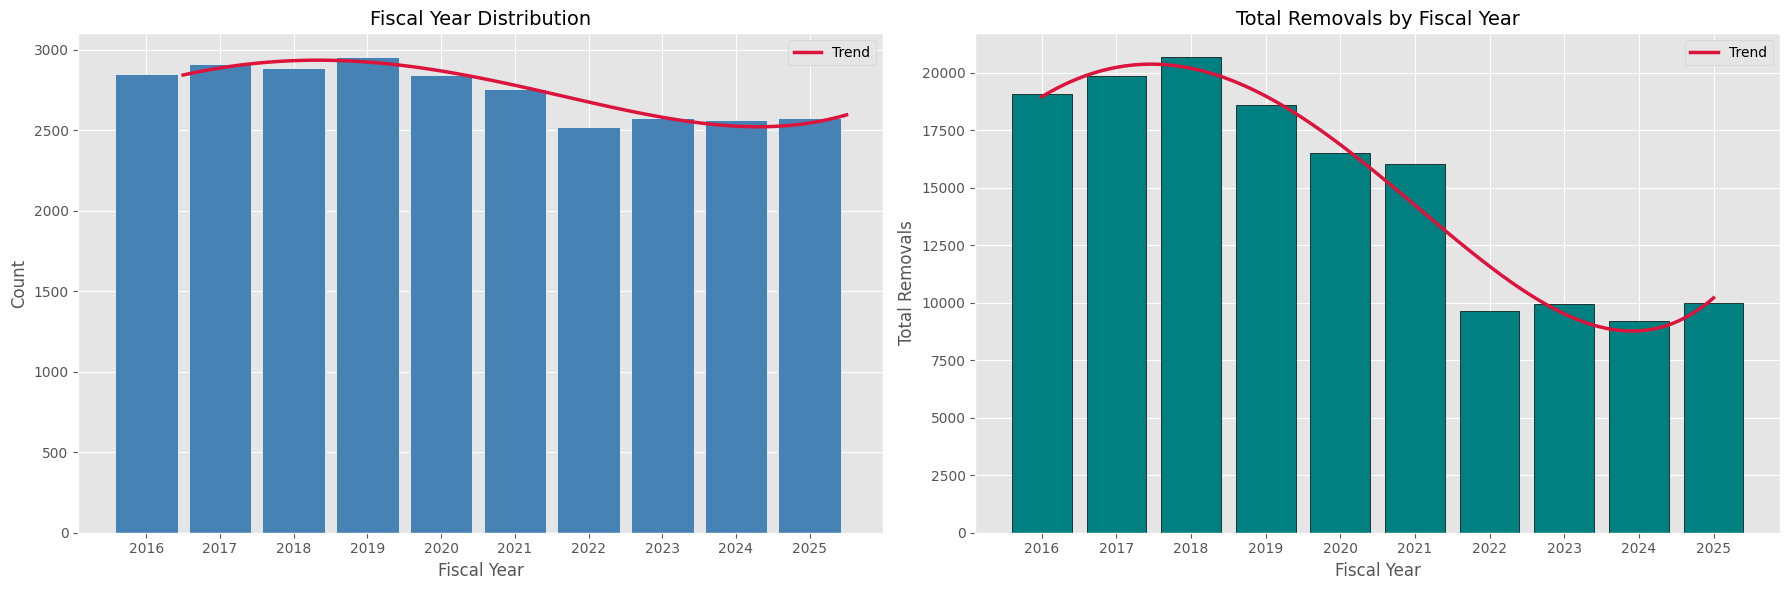

In [29]:
# Create Crosstab
ct = pd.crosstab(df['fiscal_year'], df['removals'])

# Sum removals per fiscal year (for bar chart)
removal_counts = df.groupby('fiscal_year')['removals'].sum() # the aggreated values of removals per fiscal year
# Create Subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Histogram + Polynomial Trendline
year_custom_bins = np.arange(df['fiscal_year'].min(), df['fiscal_year'].max() + 2)
counts, bin_edges, _ = axes[0].hist(
    df['fiscal_year'].dropna(),
    bins=year_custom_bins,
    color='steelblue',
    edgecolor='white',
    rwidth=0.85,
    align='left'
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

z = np.polyfit(bin_centers, counts, deg=4)
p = np.poly1d(z)
x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 100)
axes[0].plot(x_smooth, p(x_smooth), color='crimson', linewidth=2.5, label='Trend')

axes[0].set_title('Fiscal Year Distribution', fontsize=14)
axes[0].set_xlabel('Fiscal Year')
axes[0].set_ylabel('Count')
axes[0].set_xticks(np.arange(df['fiscal_year'].min(), df['fiscal_year'].max() + 1))
axes[0].legend()


# Subplot 2: Crosstab Bar Chart + Trend Line
axes[1].bar(removal_counts.index, removal_counts.values, color='teal', edgecolor='black')

# Trend line for removals per year
z2 = np.polyfit(removal_counts.index, removal_counts.values, deg=4)
p2 = np.poly1d(z2)
x_smooth2 = np.linspace(removal_counts.index.min(), removal_counts.index.max(), 100)
axes[1].plot(x_smooth2, p2(x_smooth2), color='crimson', linewidth=2.5, label='Trend')
axes[1].set_xticks(np.arange(df['fiscal_year'].min(), df['fiscal_year'].max() + 1))

axes[1].set_title('Total Removals by Fiscal Year', fontsize=14)
axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('Total Removals')
axes[1].legend()

plt.tight_layout()
plt.show()


#### **Key Finding: Age Distribution & Stability in Child Removals**

- **Age Demographics:** The age profile of children removed during family investigations (INV) or family preservation (FPR) stages is heavily skewed toward younger populations. Infants under the age of 1 experience the highest frequency of removals, while teenagers above age 16 see the lowest volume.

- **Risk & Vulnerability:** The distinct downward trend across the age spectrum highlights a clear correlation: younger, highly vulnerable children are removed at a significantly higher rate than older youth who are nearing legal adulthood.

- **Pandemic Resilience:** Interestingly, the overall average age remained remarkably stable at approximately 8.0 years old across a ten-year span (FY 2016–2025). Despite major disruptions and total caseload fluctuations caused by the COVID-19 pandemic, the baseline average age profile of impacted children was not significantly altered.

#### **Key Finding: Age Skewness and Longitudinal TrendsDistribution Analysis:**

- **Distribution Analysis:** The Age Distribution visualization demonstrates a strong right-skewed pattern. The maximum frequency count lies at Age 0 (<1 year old) with nearly 2,000 instances, decreasing incrementally down to Age 17 with roughly 1,000 instances.

- **Operational Correlation:** The data establishes an inverse relationship between child age and removal frequency, pointing to higher intervention metrics for highly vulnerable age cohorts.

- **Longitudinal Baseline:** A groupby aggregation of the average age by fiscal year demonstrates strict baseline stability. The values consistently hover between 7.7 and 8.1 years old from 2016 through 2025, proving that pandemic-era macro shifts did not change the underlying age composition of the cohorts.

In [42]:
df.groupby('fiscal_year')['age'].mean().round(1).to_frame('avg_age')

,avg_age
fiscal_year,
2016,8.0
2017,8.0
2018,8.0
2019,7.9
2020,8.1
2021,8.0
2022,7.7
2023,7.9
2024,7.8


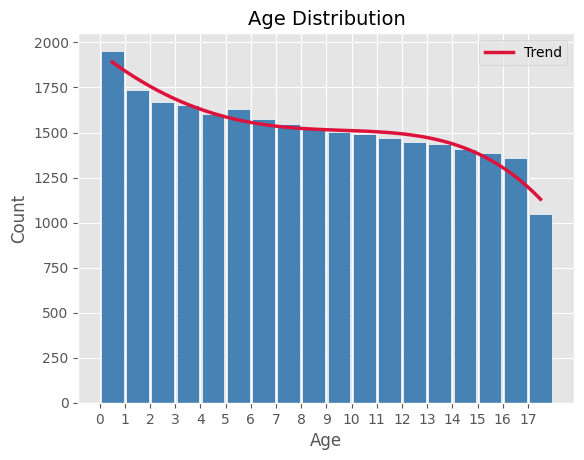

In [31]:
# Plot Histogram
custom_bins = np.arange(0, 19) 

counts, bin_edges, _ = plt.hist(
    df['age'].dropna(), 
    bins=custom_bins, 
    color='steelblue', 
    edgecolor='white',
    rwidth=0.9
)

# Calculate Bin Midpoints
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit Polynomial Trendline
z = np.polyfit(bin_centers, counts, deg=4)
p = np.poly1d(z)

# Plot Trendline
x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 100)
plt.plot(x_smooth, p(x_smooth), color='crimson', linewidth=2.5, label='Trend')
plt.xticks(np.arange(0, 18)) 


# Formatting
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

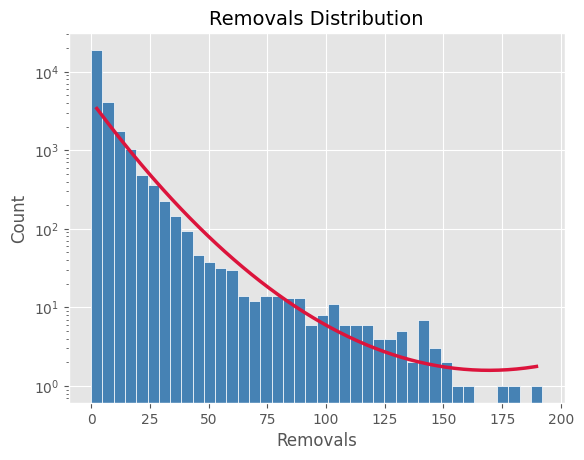

In [32]:
# Removals
# Plot Histogram
counts, bin_edges, _ = plt.hist(df['removals'].dropna(), bins=40, color='steelblue', edgecolor='white',log=True) # provide a log scale for better visualization of the distribution

# Calculate Bin Midpoints
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#Filter out zero counts to prevent log(0) mathematical errors
valid_idx = counts > 0
x_data = bin_centers[valid_idx]
y_data = counts[valid_idx]

# Fit Polynomial Trendline
log_y = np.log(y_data)
z = np.polyfit(x_data, log_y, deg=2)
p = np.poly1d(z)

# Generate smooth curve values and plot
x_smooth = np.linspace(x_data.min(), x_data.max(), 200)
y_smooth = np.exp(p(x_smooth)) # Convert back from log scale

plt.plot(x_smooth, y_smooth, color='crimson', linewidth=2.5, label='Exponential Trend')


# Formatting
plt.title('Removals Distribution', fontsize=14)
plt.xlabel('Removals')
plt.ylabel('Count')
plt.show()

### **Exploratory Data Analysis (EDA) Summary**

#### **Overview**
This exploratory analysis evaluated longitudinal Texas child welfare data from Fiscal Year 2016 through 2025, focusing on annual removal case distributions, removal volumes, and demographic profiles during family investigations (INV) and family preservation (FPR) stages. The analysis reveals a system heavily impacted by macro-environmental shocks but anchored by highly stable internal demographic baselines.

#### **Core Findings & Insights**
- **The Pandemic Shock & Operational Compression (FY 2020–2022)** Prior to 2020, removal counts maintained a steady baseline, with total removals peaking in 2018. However, the onset of the COVID-19 pandemic triggered a dramatic multi-year decline in documented removal interventions, hitting a low point in 2022. This sharp drop directly aligns with the severe operational constraints, structural shifts, and field disruptions faced by Child Protective Services (CPS) during the peak pandemic years.

- **Post-Pandemic Stabilization (FY 2023–2025)** Following the 2022 nadir (lowest point), the downward momentum flatlined. Case volumes and removal distributions stabilized, shifting into a consistent, predictable pattern with a slight upward recovery trend by 2025, indicating an operational return to a "new normal."

- **Demographic Skew Towards Early Childhood Vulnerability** The age distribution of children at the time of removal is heavily right-skewed. Infants under the age of 1 represent the highest volume of interventions (~2,000 instances), with removal counts steadily decreasing as child age increases, reaching a minimum for youth aged 17. This clearly quantifies an inverse relationship between a child's age and intervention frequency, highlighting that younger, more vulnerable cohorts are prioritized for protective actions.

- **Resiliency of the Systemic Baseline** Remarkably, while macro caseloads plummeted by roughly half during the pandemic, the longitudinal average age remained completely resilient. Aggregated data across the ten-year span shows the average age strictly locked between 7.7 and 8.1 years old. This proves that while the volume of operations changed drastically due to external factors, the underlying demographic profile of the children being served remained unchanged.

#### **Analytical Conclusion** 
The data paints a picture of a system that is highly sensitive to external societal disruptions (like COVID-19) in terms of its total bandwidth and output, yet fundamentally consistent in its targeted execution—consistently prioritizing early childhood interventions and maintaining a stable demographic center of gravity for a decade.

*Note: This is an independent project not affiliated with any government agency; please independently verify all data, conclusions, and/or calculations for accuracy.*